# Embedding Techniques for Clustering of Molecular Structures


Problem in my high dimensional data is the "Curse of Dimensionality". As we use high dimensional feature spaces the distance between points become less meaningful and the data becomes sparse. This makes it difficult for clustering algorithms to find meaningful clusters. To address this issue in the algorithm different dimensionality reduction techniques are used to reduce the number of dimensions while preserving the important information in the data.

In [76]:
from ase import Atoms
from xtb.ase.calculator import XTB
# Import read from ase 
from ase.io import read
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

Throughout this notebook we will again use the water-dimer as a test case to demonstrate different embedding techniques. Five different structures of the water-dimer are used

+ H2O_2_1 is the global minimum structure
+ H2O_2_2 is the cyclic RP structure
+ H2O_2_3 is the cyclic RNP structure
+ H2O_2_4 is the linear planar structure
+ H2O_2_5 is the BP structure

In [77]:
# SOAP feature config
from dscribe.descriptors import SOAP
r_cut = 6
n_max = 12
l_max = 8
sigma = 0.5
rbf = "gto"
average = "inner"

h2o_2_1 = read("/media/storage_6/lme/master_thesis/cluster_generation/test_molecules/water_dimer_local_minima/h2o_2_1.xyz")
h2o_2_2 = read("/media/storage_6/lme/master_thesis/cluster_generation/test_molecules/water_dimer_local_minima/h2o_2_2.xyz")
h2o_2_3 = read("/media/storage_6/lme/master_thesis/cluster_generation/test_molecules/water_dimer_local_minima/h2o_2_3.xyz")
h2o_2_4 = read("/media/storage_6/lme/master_thesis/cluster_generation/test_molecules/water_dimer_local_minima/h2o_2_4.xyz")
h2o_2_5 = read("/media/storage_6/lme/master_thesis/cluster_generation/test_molecules/water_dimer_local_minima/h2o_2_5.xyz")

# Find covalent bonds using a simple distance-based criterion
def find_bonds(atoms, cutoff=1.2):
    positions = atoms.get_positions()
    symbols = atoms.get_chemical_symbols()
    bonds = []
    for i in range(len(atoms)):
        for j in range(i + 1, len(atoms)):
            distance = np.linalg.norm(positions[i] - positions[j])
            if distance < cutoff:
                bonds.append((i, j))
    return bonds

print(find_bonds(h2o_2_1))
print(find_bonds(h2o_2_2))
print(find_bonds(h2o_2_3))
print(find_bonds(h2o_2_4))
print(find_bonds(h2o_2_5))

submol_indices_1 = [[0,1,2], [3,4,5]]
submol_indices_2 = [[0,2,3],[1,4,5]]
submol_indices_3 = [[0,2,3],[1,4,5]]
submol_indices_4 = [[0,2,3],[1,4,5]]
submol_indices_5 = [[0,2,3],[1,4,5]]

soap = SOAP(
    species=["H", "O"],
    periodic=False,
    r_cut=r_cut,
    n_max=n_max,
    l_max=l_max,
    sigma=sigma,
    rbf=rbf,
    average=average,
)

[(0, 1), (0, 2), (3, 4), (3, 5)]
[(0, 2), (0, 3), (1, 4), (1, 5)]
[(0, 2), (0, 3), (1, 4), (1, 5)]
[(0, 2), (0, 3), (1, 4), (1, 5)]
[(0, 2), (0, 3), (1, 4), (1, 5)]


The following function is used to generate small perturbed strucutres around the local minimum configurations we consider. This will aid us to generate clusters around the local minima and then see how the different embedding techniques can separate these clusters and the outliers.

In [78]:
def generate_perturbed_structures_and_features(original_structures, submol_indices, structure_labels, n_perturbations=20, perturbation_scale=0.05):
    perturbed_structures = []
    perturbed_labels = []

    for struct_idx, (original_struct, submol_idx, label) in enumerate(zip(original_structures, submol_indices, structure_labels)):
        for pert in range(n_perturbations):
            # Create a copy of the structure
            perturbed_struct = original_struct.copy()
            
            # Randomly choose which submolecule to perturb
            submol_to_perturb = np.random.choice([0, 1])
            indices_to_perturb = submol_idx[submol_to_perturb]
            
            # Generate random perturbations
            positions = perturbed_struct.get_positions()
            # Sample random vector from normal distribution and apply the perturbation scale
            random_displacement = np.random.randn(len(indices_to_perturb), 3) * perturbation_scale
            
            # Apply perturbations to selected submolecule
            # This preserves the internal structure of the submolecule while introducing noise to the overall structure
            for i, atom_idx in enumerate(indices_to_perturb):
                positions[atom_idx] += random_displacement[i]
            
            perturbed_struct.set_positions(positions)
            perturbed_structures.append(perturbed_struct)
            perturbed_labels.append(label)

    # Generate SOAP features for all perturbed structures
    perturbed_feature_matrix = soap.create(perturbed_structures)
    
    return perturbed_structures, perturbed_labels, perturbed_feature_matrix

def generate_outliers(original_structures, n_outliers=100, displacement=0.1):
    outlier_structures = []
    outlier_labels = []
    for struct_idx, original_struct in enumerate(original_structures):
        for _ in range(n_outliers // len(original_structures)):
            outlier_struct = original_struct.copy()
            positions = outlier_struct.get_positions()
            random_displacement = np.random.randn(*positions.shape) * displacement
            positions += random_displacement
            outlier_struct.set_positions(positions)
            outlier_structures.append(outlier_struct)
            # Make all into one outlier class
            outlier_labels.append("Outlier")
    return outlier_structures, outlier_labels

## Test-data set

For the test data set we use pertubation scale of $0.08$ and generate 200 perturbed structures around the 5 local minima. We also generate 100 outliers by displacing the atoms by a larger scale of $0.5$.

In [79]:
original_structures = [h2o_2_1, h2o_2_2, h2o_2_3, h2o_2_4, h2o_2_5]
structure_labels = ["(H$_2$O)$_2$-1", "(H$_2$O)$_2$-2", "(H$_2$O)$_2$-3", "(H$_2$O)$_2$-4", "(H$_2$O)$_2$-5"]
submol_indices = [submol_indices_1, submol_indices_2, submol_indices_3, submol_indices_4, submol_indices_5]
perturbed_structures, perturbed_labels, perturbed_feature_matrix = generate_perturbed_structures_and_features(original_structures, submol_indices, structure_labels, n_perturbations=200, perturbation_scale=0.08)
# Generate outliers
outlier_structures, outlier_labels = generate_outliers(original_structures, n_outliers=100, displacement=0.5)
# Combine perturbed structures and outliers
all_structures = perturbed_structures + outlier_structures
all_labels = perturbed_labels + outlier_labels
# Create the feature matrix for all structures (perturbed + outliers)
all_feature_matrix = soap.create(all_structures)
print("Feature matrix shape:", all_feature_matrix.shape)

# compute the features of the original structures as well for visualization purposes
original_feature_matrix = soap.create(original_structures)
print("Original feature matrix shape:", original_feature_matrix.shape)

print(all_labels)

Feature matrix shape: (1100, 2700)
Original feature matrix shape: (5, 2700)
['(H$_2$O)$_2$-1', '(H$_2$O)$_2$-1', '(H$_2$O)$_2$-1', '(H$_2$O)$_2$-1', '(H$_2$O)$_2$-1', '(H$_2$O)$_2$-1', '(H$_2$O)$_2$-1', '(H$_2$O)$_2$-1', '(H$_2$O)$_2$-1', '(H$_2$O)$_2$-1', '(H$_2$O)$_2$-1', '(H$_2$O)$_2$-1', '(H$_2$O)$_2$-1', '(H$_2$O)$_2$-1', '(H$_2$O)$_2$-1', '(H$_2$O)$_2$-1', '(H$_2$O)$_2$-1', '(H$_2$O)$_2$-1', '(H$_2$O)$_2$-1', '(H$_2$O)$_2$-1', '(H$_2$O)$_2$-1', '(H$_2$O)$_2$-1', '(H$_2$O)$_2$-1', '(H$_2$O)$_2$-1', '(H$_2$O)$_2$-1', '(H$_2$O)$_2$-1', '(H$_2$O)$_2$-1', '(H$_2$O)$_2$-1', '(H$_2$O)$_2$-1', '(H$_2$O)$_2$-1', '(H$_2$O)$_2$-1', '(H$_2$O)$_2$-1', '(H$_2$O)$_2$-1', '(H$_2$O)$_2$-1', '(H$_2$O)$_2$-1', '(H$_2$O)$_2$-1', '(H$_2$O)$_2$-1', '(H$_2$O)$_2$-1', '(H$_2$O)$_2$-1', '(H$_2$O)$_2$-1', '(H$_2$O)$_2$-1', '(H$_2$O)$_2$-1', '(H$_2$O)$_2$-1', '(H$_2$O)$_2$-1', '(H$_2$O)$_2$-1', '(H$_2$O)$_2$-1', '(H$_2$O)$_2$-1', '(H$_2$O)$_2$-1', '(H$_2$O)$_2$-1', '(H$_2$O)$_2$-1', '(H$_2$O)$_2$-1', '(H$_

# Test of Embedding Techniques

As a test of the embedding techniques we will use K-Means clustering as a simple clustering algorithm with $k=5$ to see how well the different embedding techniques can support the clustering of the perturbed structures.

As a validation (since our labels are known) we will use the adjusted rand index (ARI) which calculates how many pairs of points are "correctly handled" with respect to the true labels. The ARI is adjusted for chance, meaning that it will give a score of 0 for random labeling and a score of 1 for perfect labeling.

And we will use the Normalized Mutual Information (NMI) which measures the "amount of shared information" between the true labels and the predicted labels. The NMI is normalized to be between 0 and 1, where 0 indicates no mutual information and 1 indicates perfect correlation.

Finally we will use the V-Measure (Homogeneity and Completeness) which is the harmonic mean of homogeneity and completeness. Homogeneity measures how much each cluster contains only members of a single class, while completeness measures how much all members of a given class are assigned to the same cluster. The V-Measure is also between 0 and 1, where 1 indicates perfect clustering.

## K-Means on Raw Features

In [80]:
# Use K-Means on raw feature space and calculate ARI, NMI, and V-Measure
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, v_measure_score
kmeans = KMeans(n_clusters=5, random_state=42)
predicted_labels = kmeans.fit_predict(all_feature_matrix)
ari = adjusted_rand_score(all_labels, predicted_labels)
nmi = normalized_mutual_info_score(all_labels, predicted_labels)
v_measure = v_measure_score(all_labels, predicted_labels)
print(f"ARI: {ari:.4f}, NMI: {nmi:.4f}, V-Measure: {v_measure:.4f}")


ARI: 0.5083, NMI: 0.6331, V-Measure: 0.6331


The NMI and V-Measure for this high dimensional data is quite strong, but the ARI still indicates that the clustering is not perfect. We now will see the influence of embedding methods on the clustering performance.

### PCA

Next we use the PCA and reduce to a embedding space that explains 95% of the variance in the data. We then apply K-Means on this PCA embedding and calculate the ARI, NMI, and V-Measure again to see if we have an improvement in the clustering performance. We further visualize the 3D PCA embedding to see how well the clusters are separated in this space.

PCA embedding shape: (1100, 6)
PCA ARI: 0.5319, PCA NMI: 0.6547, PCA V-Measure: 0.6547


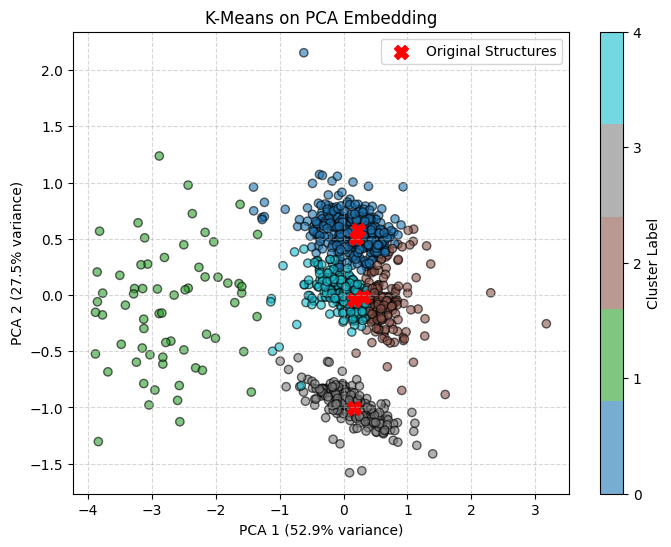

In [81]:
from sklearn.decomposition import PCA
pca = PCA(n_components=0.95)  # Keep 95% of variance
pca_embedding = pca.fit_transform(all_feature_matrix)
# Embedd the original structures in the same PCA space for visualization


print("PCA embedding shape:", pca_embedding.shape)
# Apply K-Means on PCA embedding
predicted_labels_pca = kmeans.fit_predict(pca_embedding)
ari_pca = adjusted_rand_score(all_labels, predicted_labels_pca)
nmi_pca = normalized_mutual_info_score(all_labels, predicted_labels_pca)
v_measure_pca = v_measure_score(all_labels, predicted_labels_pca)
print(f"PCA ARI: {ari_pca:.4f}, PCA NMI: {nmi_pca:.4f}, PCA V-Measure: {v_measure_pca:.4f}")

# Plot the Clustered data in 2D PCA space
plt.figure(figsize=(8, 6))
# Scatter plot of the PCA embedding colored by predicted cluster labels
# CMAP
# Only the amount of colors we have clusters
cmap = plt.get_cmap('tab10', np.unique(predicted_labels_pca).size)


scatter = plt.scatter(pca_embedding[:, 0], pca_embedding[:, 1], c=predicted_labels_pca, cmap=cmap, alpha=0.6, edgecolor='k')
plt.colorbar(scatter, label='Cluster Label', ticks=np.arange(np.unique(predicted_labels_pca).size))
# Plot original structures in the same PCA space with different markers
original_pca_embedding = pca.transform(original_feature_matrix)
plt.scatter(original_pca_embedding[:, 0], original_pca_embedding[:, 1], c='red', marker='X', s=100, label='Original Structures')
plt.title("K-Means on PCA Embedding")
plt.xlabel(f"PCA 1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PCA 2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.legend()
plt.grid(linestyle='--', alpha=0.5)
plt.show()

## Kernel PCA
Aims to capture non-linear relationship by applying the kernel trick. Instead of eigen-decomposition of the covariance matrix, KPCA first maps data into a higher dimensional feature space using a nonlinear kernel function.


Number of components needed for 95% variance: 6
Kernel PCA embedding shape (gamma=0.01): (1100, 6)
Kernel PCA (gamma=0.01) ARI: 0.5919, NMI: 0.7534, V-Measure: 0.7534
Kernel PCA embedding shape (gamma=0.1): (1100, 6)
Kernel PCA (gamma=0.1) ARI: 0.5271, NMI: 0.6439, V-Measure: 0.6439
Kernel PCA embedding shape (gamma=0.5): (1100, 6)
Kernel PCA (gamma=0.5) ARI: 0.5783, NMI: 0.7157, V-Measure: 0.7157
Kernel PCA embedding shape (gamma=1): (1100, 6)
Kernel PCA (gamma=1) ARI: 0.5798, NMI: 0.7177, V-Measure: 0.7177


/tmp/ipykernel_1940696/71271633.py:40: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


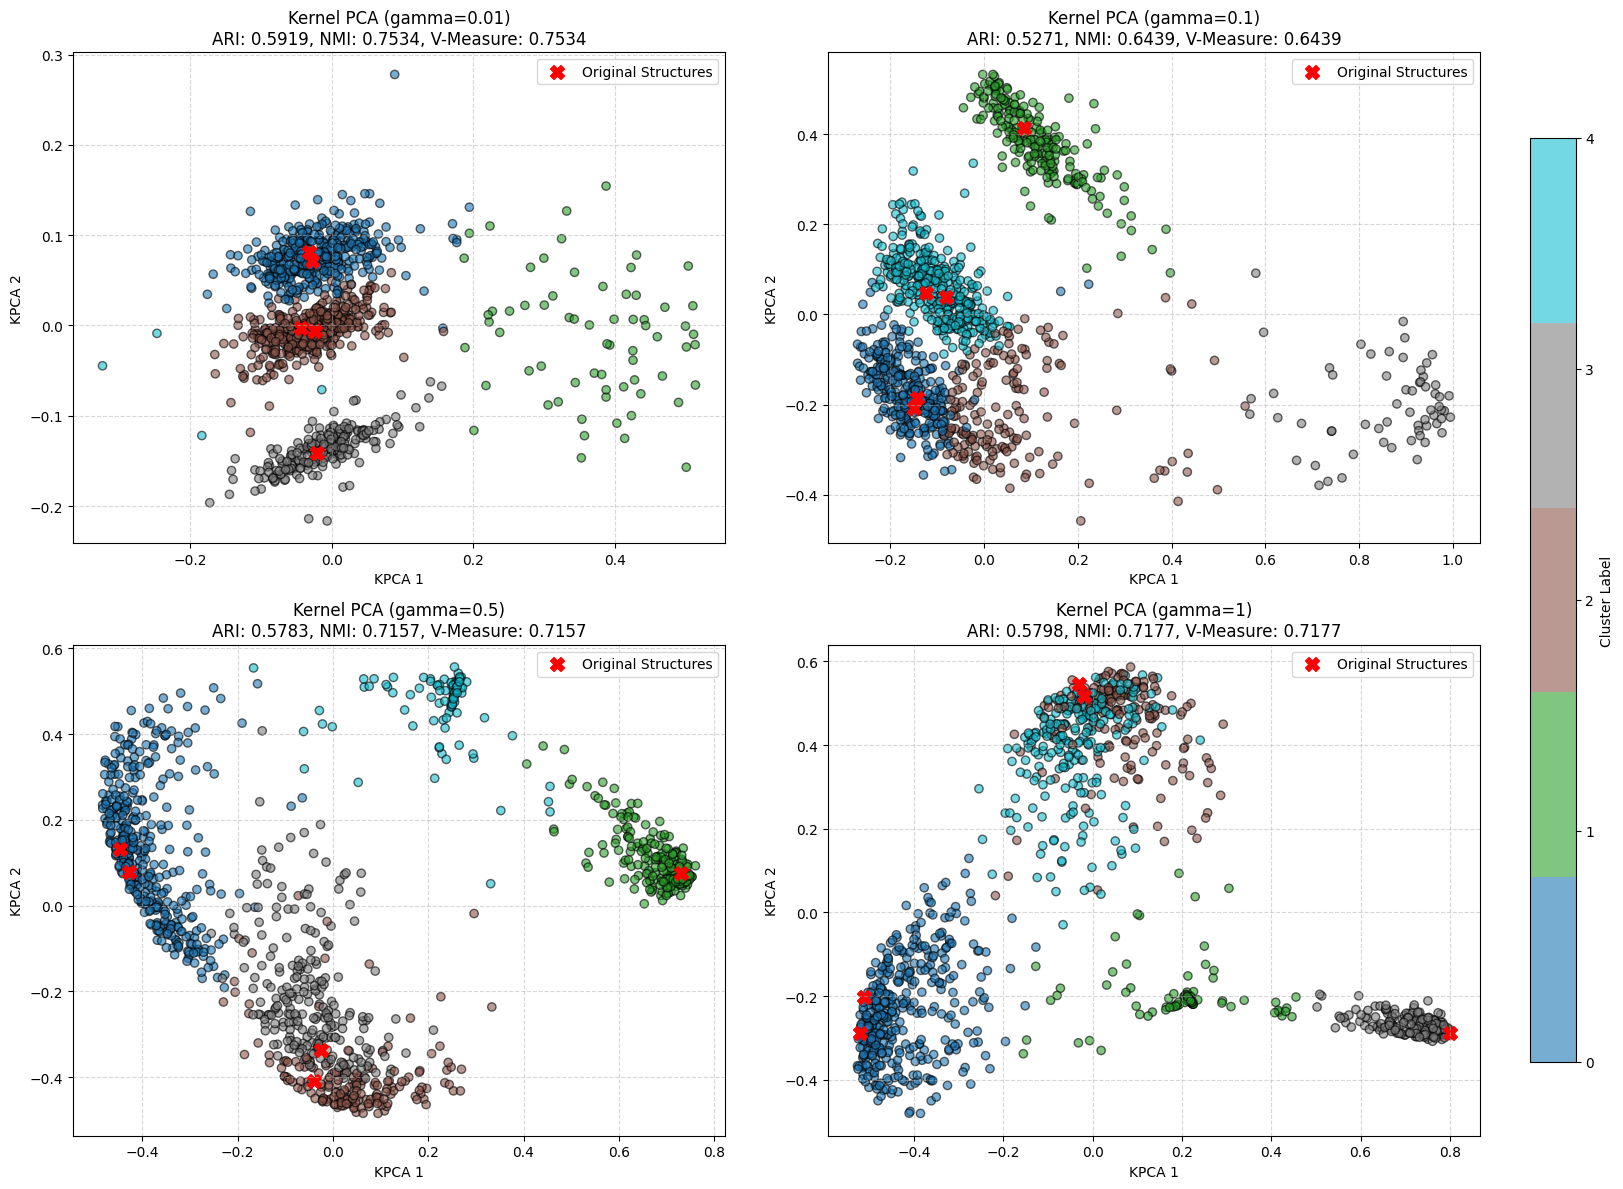

In [82]:
# Perform Kernel PCA with RBF kernel
from sklearn.decomposition import KernelPCA
gammas = [0.01, 0.1, 0.5, 1]

# obtain the number needed for 95% variance in the original space to set n_components for KPCA
pca_full = PCA(n_components=None)
pca_full.fit(all_feature_matrix)
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
n_components_95 = np.searchsorted(cumulative_variance, 0.95) + 1
print(f"Number of components needed for 95% variance: {n_components_95}")

# We perform for all different gammas an plot in the 4x4 grid
# We apply PCA to obtain 95% of variance for visualization purposes
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
for i, gamma in enumerate(gammas):
    kpca = KernelPCA(n_components=n_components_95, kernel='rbf', gamma=gamma, random_state=42)
    kpca_embedding = kpca.fit_transform(all_feature_matrix)
    print(f"Kernel PCA embedding shape (gamma={gamma}):", kpca_embedding.shape)
    
    # Apply K-Means on KPCA embedding
    predicted_labels_kpca = kmeans.fit_predict(kpca_embedding)
    ari_kpca = adjusted_rand_score(all_labels, predicted_labels_kpca)
    nmi_kpca = normalized_mutual_info_score(all_labels, predicted_labels_kpca)
    v_measure_kpca = v_measure_score(all_labels, predicted_labels_kpca)
    print(f"Kernel PCA (gamma={gamma}) ARI: {ari_kpca:.4f}, NMI: {nmi_kpca:.4f}, V-Measure: {v_measure_kpca:.4f}")
    
    # Plot the Clustered data in 2D KPCA space
    ax = axes[i // 2, i % 2]
    scatter = ax.scatter(kpca_embedding[:, 0], kpca_embedding[:, 1], c=predicted_labels_kpca, cmap=cmap, alpha=0.6, edgecolor='k')
    ax.set_title(f"Kernel PCA (gamma={gamma})\nARI: {ari_kpca:.4f}, NMI: {nmi_kpca:.4f}, V-Measure: {v_measure_kpca:.4f}")
    ax.set_xlabel("KPCA 1")
    ax.set_ylabel("KPCA 2")
    ax.grid(linestyle='--', alpha=0.5)
    # Compute original structures in the same KPCA space for visualization
    original_kpca_embedding = kpca.transform(original_feature_matrix)
    ax.scatter(original_kpca_embedding[:, 0], original_kpca_embedding[:, 1], c='red', marker='X', s=100, label='Original Structures')
    ax.legend()
# global colorbar horizontal at the bottom
fig.colorbar(scatter, ax=axes, orientation='vertical', location="right", label='Cluster Label', ticks=np.arange(np.unique(predicted_labels_kpca).size), anchor=(2.8, 0.5))
plt.tight_layout()
plt.show()

This also shows that if the right kernel is chosen, the clustering performance can be improved significantly in respect to normal PCA. The problem here of course is that one does not know a priori which kernel is the right one to use and which parameters to choose for the given kernel.

## TSNE

TSNE is a non-linear dimensionality reduction technique that is particularly well-suited for visualizing high-dimensional data in 2 or 3 dimensions. It works by minimizing the divergence between two distributions: one that measures pairwise similarities of the input data points in the high-dimensional space, and another that measures pairwise similarities of the corresponding low-dimensional points in the embedding space.

t-SNE embedding shape (perplexity=5): (1100, 2)
t-SNE (perplexity=5) ARI: 0.4815, NMI: 0.6034, V-Measure: 0.6034
t-SNE embedding shape (perplexity=10): (1100, 2)
t-SNE (perplexity=10) ARI: 0.5202, NMI: 0.6534, V-Measure: 0.6534
t-SNE embedding shape (perplexity=30): (1100, 2)
t-SNE (perplexity=30) ARI: 0.5087, NMI: 0.6423, V-Measure: 0.6423
t-SNE embedding shape (perplexity=50): (1100, 2)
t-SNE (perplexity=50) ARI: 0.5232, NMI: 0.6545, V-Measure: 0.6545


/tmp/ipykernel_1940696/1508279825.py:25: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


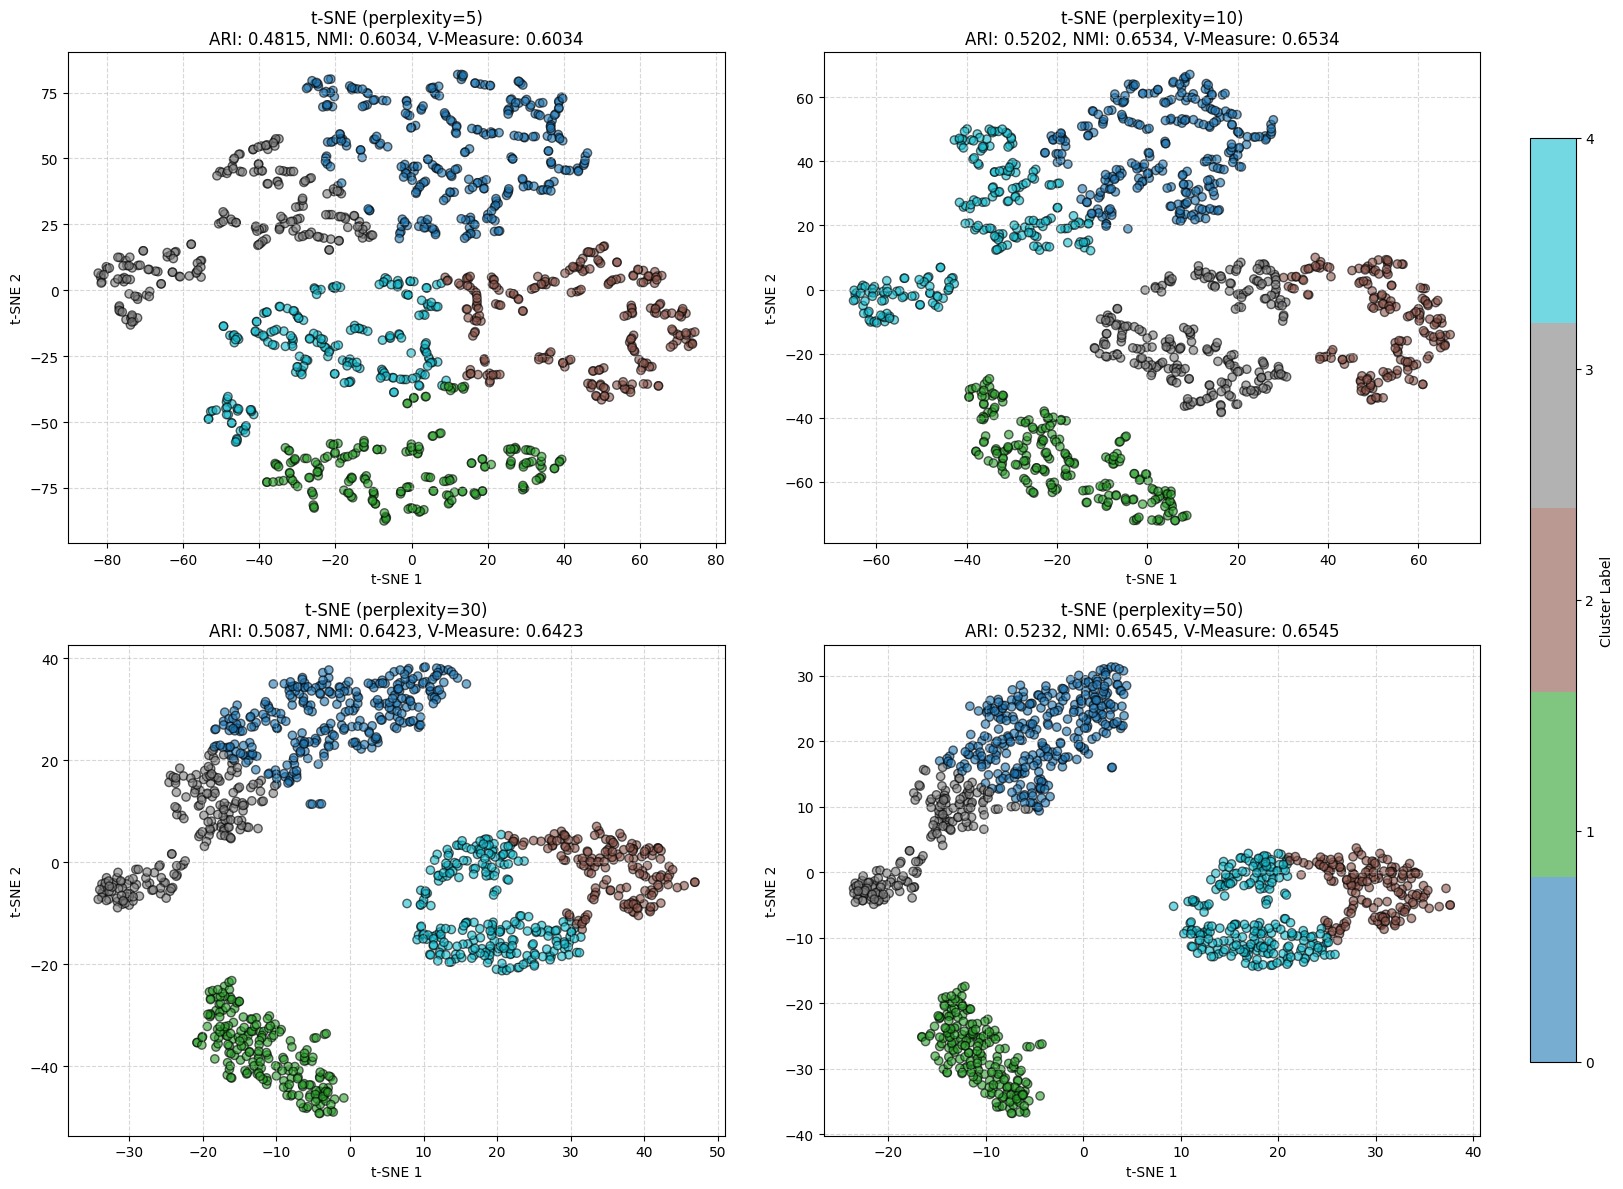

In [83]:
from sklearn.manifold import TSNE
perplexities = [5, 10, 30, 50]
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
for i, perplexity in enumerate(perplexities):
    tsne = TSNE(n_components=2, perplexity=perplexity, random_state=42)
    tsne_embedding = tsne.fit_transform(all_feature_matrix)
    print(f"t-SNE embedding shape (perplexity={perplexity}):", tsne_embedding.shape)
    
    # Apply K-Means on t-SNE embedding
    predicted_labels_tsne = kmeans.fit_predict(tsne_embedding)
    ari_tsne = adjusted_rand_score(all_labels, predicted_labels_tsne)
    nmi_tsne = normalized_mutual_info_score(all_labels, predicted_labels_tsne)
    v_measure_tsne = v_measure_score(all_labels, predicted_labels_tsne)
    print(f"t-SNE (perplexity={perplexity}) ARI: {ari_tsne:.4f}, NMI: {nmi_tsne:.4f}, V-Measure: {v_measure_tsne:.4f}")
    
    # Plot the Clustered data in 2D t-SNE space
    ax = axes[i // 2, i % 2]
    scatter = ax.scatter(tsne_embedding[:, 0], tsne_embedding[:, 1], c=predicted_labels_tsne, cmap=cmap, alpha=0.6, edgecolor='k')
    ax.set_title(f"t-SNE (perplexity={perplexity})\nARI: {ari_tsne:.4f}, NMI: {nmi_tsne:.4f}, V-Measure: {v_measure_tsne:.4f}")
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")
    ax.grid(linestyle='--', alpha=0.5)
# Add global colorbar horizontal at the bottom
fig.colorbar(scatter, ax=axes, orientation='vertical', location="right", label='Cluster Label', ticks=np.arange(np.unique(predicted_labels_tsne).size), anchor=(2.8, 0.5))
plt.tight_layout()
plt.show()

# Isomap

Isomap is another non-linear dimensionality reduction technique that seeks to preserve the geodesic distances between data points in the high-dimensional space when embedding them into a lower-dimensional space. It does this by constructing a neighborhood graph of the data points, computing the shortest paths (geodesic distances) between all pairs of points in this graph, and then applying classical MDS (Multidimensional Scaling) to these distances to find the low-dimensional embedding.


Isomap embedding shape (n_neighbors=5): (1100, 2)
Isomap (n_neighbors=5) ARI: 0.4974, NMI: 0.6239, V-Measure: 0.6239
Isomap embedding shape (n_neighbors=10): (1100, 2)
Isomap (n_neighbors=10) ARI: 0.5957, NMI: 0.7541, V-Measure: 0.7541
Isomap embedding shape (n_neighbors=15): (1100, 2)
Isomap (n_neighbors=15) ARI: 0.5726, NMI: 0.7044, V-Measure: 0.7044
Isomap embedding shape (n_neighbors=30): (1100, 2)
Isomap (n_neighbors=30) ARI: 0.4451, NMI: 0.5686, V-Measure: 0.5686


/tmp/ipykernel_1940696/1872820027.py:30: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


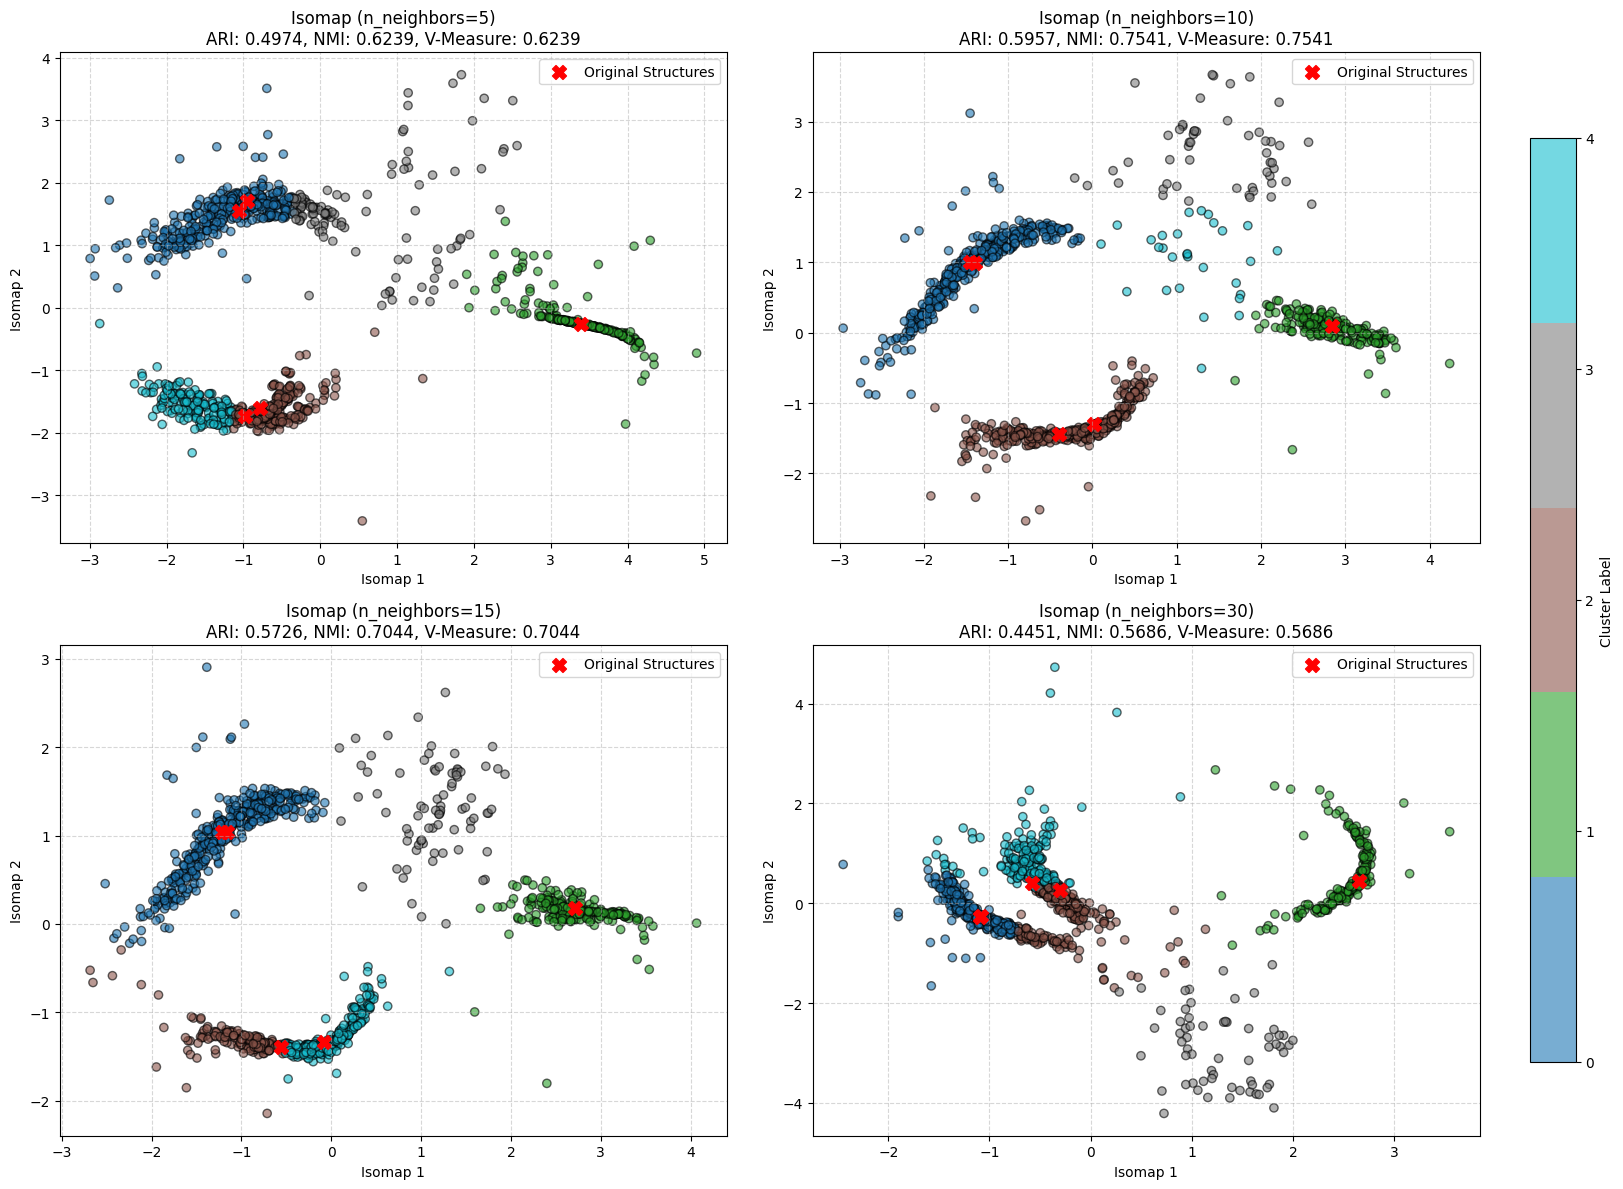

In [84]:
from sklearn.manifold import Isomap

n_neighbors = [5, 10, 15, 30]
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
for i, n_neighbor in enumerate(n_neighbors):
    isomap = Isomap(n_neighbors=n_neighbor, n_components=2)
    isomap_embedding = isomap.fit_transform(all_feature_matrix)
    print(f"Isomap embedding shape (n_neighbors={n_neighbor}):", isomap_embedding.shape)
    
    # Apply K-Means on Isomap embedding
    predicted_labels_isomap = kmeans.fit_predict(isomap_embedding)
    ari_isomap = adjusted_rand_score(all_labels, predicted_labels_isomap)
    nmi_isomap = normalized_mutual_info_score(all_labels, predicted_labels_isomap)
    v_measure_isomap = v_measure_score(all_labels, predicted_labels_isomap)
    print(f"Isomap (n_neighbors={n_neighbor}) ARI: {ari_isomap:.4f}, NMI: {nmi_isomap:.4f}, V-Measure: {v_measure_isomap:.4f}")
    
    # Plot the Clustered data in 2D Isomap space
    ax = axes[i // 2, i % 2]
    scatter = ax.scatter(isomap_embedding[:, 0], isomap_embedding[:, 1], c=predicted_labels_isomap, cmap=cmap, alpha=0.6, edgecolor='k')
    ax.set_title(f"Isomap (n_neighbors={n_neighbor})\nARI: {ari_isomap:.4f}, NMI: {nmi_isomap:.4f}, V-Measure: {v_measure_isomap:.4f}")
    ax.set_xlabel("Isomap 1")
    ax.set_ylabel("Isomap 2")
    ax.grid(linestyle='--', alpha=0.5)
    # Compute original structures in the same Isomap space for visualization
    original_isomap_embedding = isomap.transform(original_feature_matrix)
    ax.scatter(original_isomap_embedding[:, 0], original_isomap_embedding[:, 1], c='red', marker='X', s=100, label='Original Structures')
    ax.legend()
# Add global colorbar horizontal at the bottom
fig.colorbar(scatter, ax=axes, orientation='vertical', location="right", label='Cluster Label', ticks=np.arange(np.unique(predicted_labels_isomap).size), anchor=(2.8, 0.5))
plt.tight_layout()
plt.show()


## UMAP

Problem with UMAP again is that it is very dependent on the choice of the hyperparameters.

**n_neighbors**

Controls how UMAP balances local versus global structure in the data. A smaller value of n_neighbors will focus more on local structure, while a larger value will capture more global structure. The optimal value depends on the specific dataset and the desired level of detail in the embedding.

**min_dist**

Parameter controls how tightly UMAP packs points together. Low values of min_dist will result in a more clustered embedding, while higher values will create a more spread-out embedding. The optimal value depends on the specific dataset and the desired level of clustering in the embedding.

**n_components**
Controls the dimensionality of the embedding space. A higher value will capture more variance in the data, but may also lead to overfitting. The optimal value depends on the specific dataset and the desired level of detail in the embedding.



/home/lme/.conda/envs/p4env/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP embedding shape (n_neighbors=5): (1100, 2)
UMAP (n_neighbors=5) ARI: 0.5412, NMI: 0.6650, V-Measure: 0.6650


/home/lme/.conda/envs/p4env/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP embedding shape (n_neighbors=10): (1100, 2)
UMAP (n_neighbors=10) ARI: 0.6340, NMI: 0.7276, V-Measure: 0.7276


/home/lme/.conda/envs/p4env/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP embedding shape (n_neighbors=15): (1100, 2)
UMAP (n_neighbors=15) ARI: 0.5380, NMI: 0.6610, V-Measure: 0.6610


/home/lme/.conda/envs/p4env/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP embedding shape (n_neighbors=30): (1100, 2)
UMAP (n_neighbors=30) ARI: 0.5309, NMI: 0.6569, V-Measure: 0.6569


/tmp/ipykernel_1940696/831221805.py:29: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


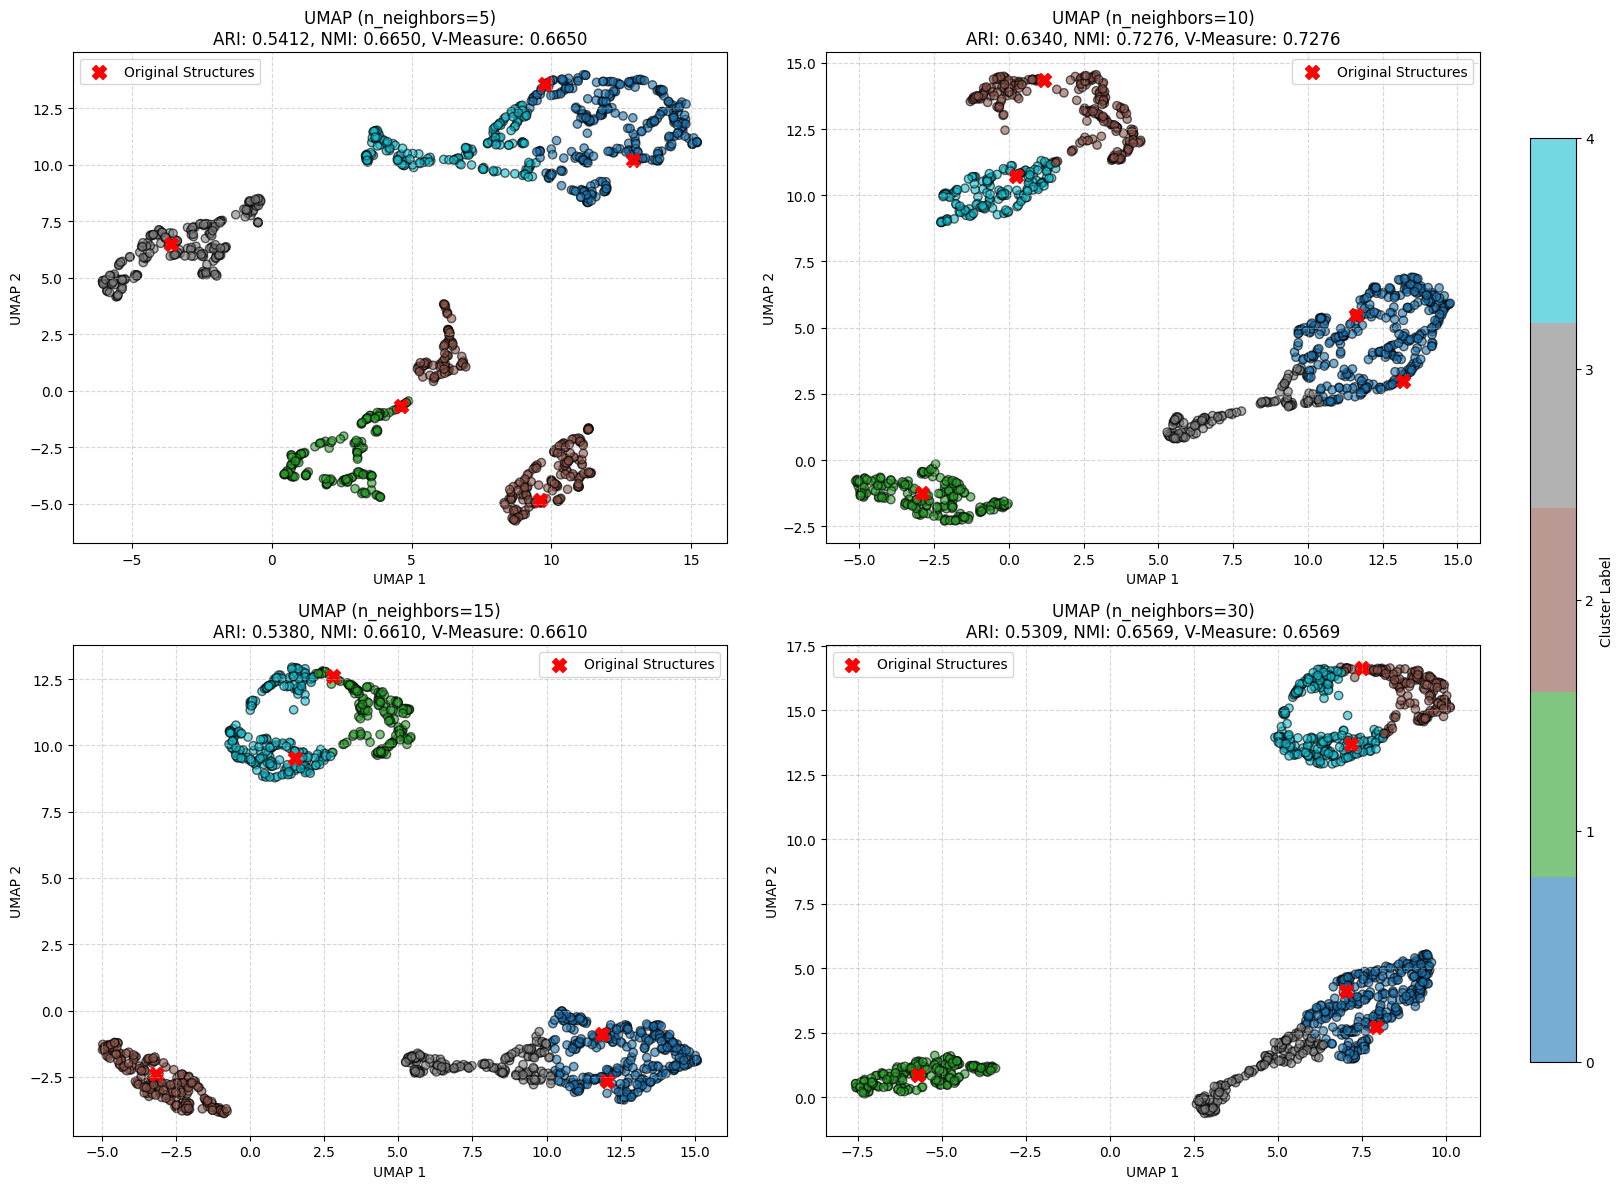

In [85]:
import umap
n_neig = [5, 10, 15, 30]
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
for i, n in enumerate(n_neig):
    reducer = umap.UMAP(n_neighbors=n, random_state=42)
    umap_embedding = reducer.fit_transform(all_feature_matrix)
    print(f"UMAP embedding shape (n_neighbors={n}):", umap_embedding.shape)
    
    # Apply K-Means on UMAP embedding
    predicted_labels_umap = kmeans.fit_predict(umap_embedding)
    ari_umap = adjusted_rand_score(all_labels, predicted_labels_umap)
    nmi_umap = normalized_mutual_info_score(all_labels, predicted_labels_umap)
    v_measure_umap = v_measure_score(all_labels, predicted_labels_umap)
    print(f"UMAP (n_neighbors={n}) ARI: {ari_umap:.4f}, NMI: {nmi_umap:.4f}, V-Measure: {v_measure_umap:.4f}")
    
    # Plot the Clustered data in 2D UMAP space
    ax = axes[i // 2, i % 2]
    scatter = ax.scatter(umap_embedding[:, 0], umap_embedding[:, 1], c=predicted_labels_umap, cmap=cmap, alpha=0.6, edgecolor='k')
    ax.set_title(f"UMAP (n_neighbors={n})\nARI: {ari_umap:.4f}, NMI: {nmi_umap:.4f}, V-Measure: {v_measure_umap:.4f}")
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")
    ax.grid(linestyle='--', alpha=0.5)
    # Compute original structures in the same UMAP space for visualization
    original_umap_embedding = reducer.transform(original_feature_matrix)
    ax.scatter(original_umap_embedding[:, 0], original_umap_embedding[:, 1], c='red', marker='X', s=100, label='Original Structures')
    ax.legend()
# global colorbar horizontal at the bottom
fig.colorbar(scatter, ax=axes, orientation='vertical', location="right", label='Cluster Label', ticks=np.arange(np.unique(predicted_labels_umap).size), anchor=(2.8, 0.5))
plt.tight_layout()
plt.show()

This shows that UMAP can capture the clusters in the data quite well, but note that in the above plots only 2 components are used. In a final algorithm for example it would be suitable to use even more components to capture more structure in the data and for example embedd into a space with about 10 - 20 dimensions

/home/lme/.conda/envs/p4env/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP 3D embedding shape: (1100, 3)
UMAP 3D ARI: 0.5989, NMI: 0.6963, V-Measure: 0.6963


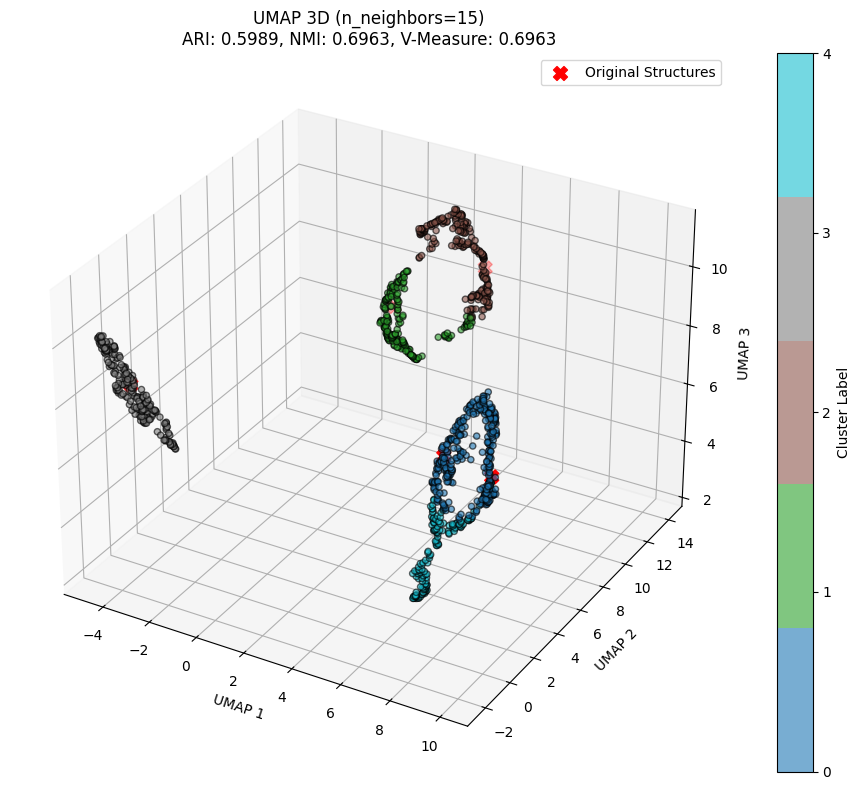

In [86]:
# UMAP in 3D
reducer = umap.UMAP(n_neighbors=15, n_components=3, random_state=42)
umap_embedding_3d = reducer.fit_transform(all_feature_matrix)
print("UMAP 3D embedding shape:", umap_embedding_3d.shape)
# Apply K-Means on UMAP 3D embedding
predicted_labels_umap_3d = kmeans.fit_predict(umap_embedding_3d)
ari_umap_3d = adjusted_rand_score(all_labels, predicted_labels_umap_3d)
nmi_umap_3d = normalized_mutual_info_score(all_labels, predicted_labels_umap_3d)
v_measure_umap_3d = v_measure_score(all_labels, predicted_labels_umap_3d)
print(f"UMAP 3D ARI: {ari_umap_3d:.4f}, NMI: {nmi_umap_3d:.4f}, V-Measure: {v_measure_umap_3d:.4f}")

# Plot the Clustered data in 3D UMAP space
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(umap_embedding_3d[:, 0], umap_embedding_3d[:, 1], umap_embedding_3d[:, 2], c=predicted_labels_umap_3d, cmap=cmap, alpha=0.6, edgecolor='k')
ax.set_title(f"UMAP 3D (n_neighbors=15)\nARI: {ari_umap_3d:.4f}, NMI: {nmi_umap_3d:.4f}, V-Measure: {v_measure_umap_3d:.4f}")
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
ax.set_zlabel("UMAP 3")
ax.grid(linestyle='--', alpha=0.5)
# Compute original structures in the same UMAP 3D space for visualization
original_umap_embedding_3d = reducer.transform(original_feature_matrix)
ax.scatter(original_umap_embedding_3d[:, 0], original_umap_embedding_3d[:, 1], original_umap_embedding_3d[:, 2], c='red', marker='X', s=100, label='Original Structures')
ax.legend()
# global colorbar horizontal at the bottom
fig.colorbar(scatter, ax=ax, orientation='vertical', label='Cluster Label', ticks=np.arange(np.unique(predicted_labels_umap_3d).size))
plt.tight_layout()
plt.show()

In [87]:
# Example keep 10 dimensions for UMAP then cluster and evaluate
reducer = umap.UMAP(n_neighbors=15, n_components=10, random_state=42)
umap_embedding_10d = reducer.fit_transform(all_feature_matrix)
print("UMAP 10D embedding shape:", umap_embedding_10d.shape)
# Apply K-Means on UMAP 10D embedding
predicted_labels_umap_10d = kmeans.fit_predict(umap_embedding_10d)
ari_umap_10d = adjusted_rand_score(all_labels, predicted_labels_umap_10d)
nmi_umap_10d = normalized_mutual_info_score(all_labels, predicted_labels_umap_10d)
v_measure_umap_10d = v_measure_score(all_labels, predicted_labels_umap_10d)
print(f"UMAP 10D ARI: {ari_umap_10d:.4f}, NMI: {nmi_umap_10d:.4f}, V-Measure: {v_measure_umap_10d:.4f}")


/home/lme/.conda/envs/p4env/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP 10D embedding shape: (1100, 10)
UMAP 10D ARI: 0.5673, NMI: 0.6839, V-Measure: 0.6839
